In [1]:
# Install dependencies
# Run once; comment out after first execution
# !pip install geopandas rasterio shapely pyproj requests tqdm torch torchvision
# !pip install segmentation-models-pytorch timm einops
# !pip install clay-foundation  # or clone: git clone https://github.com/Clay-foundation/model

import os
import json
import math
import warnings
import requests
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.transform import from_bounds
from rasterio.enums import Resampling
from shapely.geometry import box, mapping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Project directories ─────────────────────────────────────────────────────
BASE_DIR   = Path('data')
IMG_DIR    = BASE_DIR / 'imagery'
VECTOR_DIR = BASE_DIR / 'vector'
LABEL_DIR  = BASE_DIR / 'labels'
MODEL_DIR  = Path('models')
OUTPUT_DIR = Path('outputs')

for d in [IMG_DIR/'2024', IMG_DIR/'2025', VECTOR_DIR,
          LABEL_DIR, MODEL_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories ready.')

Device: cpu
Directories ready.


In [4]:
ODP_URLS = {
    'parcels':     'https://opendata.arcgis.com/datasets/84baed491de44f539889f2af178ad85c_0.geojson',
    'violations':  'https://phl.carto.com/api/v2/sql?q=SELECT+*+FROM+li_violations&format=geojson',
    'clean_seal':  'https://phl.carto.com/api/v2/sql?q=SELECT+*+FROM+clean_seal&filename=clean_seal&format=geojson&skipfields=cartodb_id',
    'permits':     'https://hub.arcgis.com/api/v3/datasets/8d18914ff740444793937d8724c64da8_0/downloads/data?format=geojson&spatialRefId=4326&where=1%3D1',
}

# NOTE: URLs above are illustrative — verify current endpoints at opendataphilly.org
# The PWD parcel layer is also available as a shapefile download.

def fetch_geojson(name: str, url: str, dest: Path) -> gpd.GeoDataFrame:
    fpath = dest / f'{name}.geojson'
    if not fpath.exists():
        print(f'Fetching {name}...')
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        fpath.write_bytes(r.content)
    return gpd.read_file(fpath)

parcels    = fetch_geojson('parcels',    ODP_URLS['parcels'],    VECTOR_DIR)
violations = fetch_geojson('violations', ODP_URLS['violations'], VECTOR_DIR)
clean_seal = fetch_geojson('clean_seal', ODP_URLS['clean_seal'], VECTOR_DIR)
permits    = fetch_geojson('permits',    ODP_URLS['permits'],    VECTOR_DIR)

# Standardise CRS to Philadelphia's standard local projection
CRS = 'EPSG:2272'   # Pennsylvania State Plane South, feet
parcels    = parcels.to_crs(CRS)
violations = violations.to_crs(CRS)
clean_seal = clean_seal.to_crs(CRS)
permits    = permits.to_crs(CRS)

print(f'Parcels: {len(parcels):,}')
print(f'Violations: {len(violations):,}')
print(f'Clean & Seal: {len(clean_seal):,}')
print(f'Permits: {len(permits):,}')

Fetching permits...
Parcels: 547,290
Violations: 1,451,562
Clean & Seal: 106,366
Permits: 13,888


Fetching imm_dang...
  rows: 136
Fetching unsafe...
  rows: 3,261
Labeled Imminently Dangerous: 134
Labeled Unsafe:               3,159
Labeled Stable:               543,997


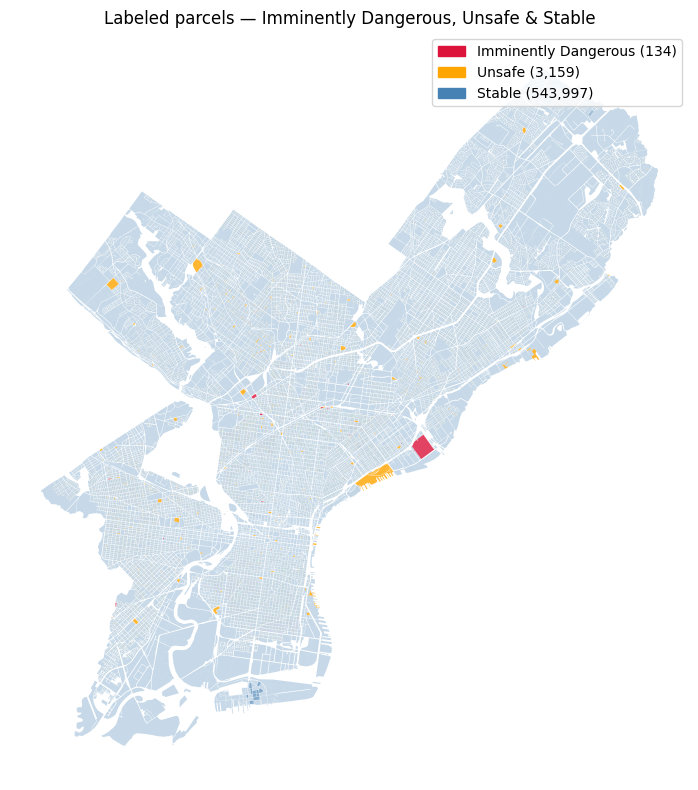

In [15]:
import requests
import geopandas as gpd
import matplotlib.patches as mpatches

# ── Pull both violation tables as GeoJSON from Carto API ────────────────────
def fetch_carto_geojson(table: str) -> gpd.GeoDataFrame:
    url = f"https://phl.carto.com/api/v2/sql?format=GeoJSON&q=SELECT * FROM {table}"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return gpd.read_file(r.text, driver='GeoJSON')

print("Fetching imm_dang...")
imm_dang = fetch_carto_geojson("imm_dang").to_crs(parcels.crs)
print(f"  rows: {len(imm_dang):,}")

print("Fetching unsafe...")
unsafe = fetch_carto_geojson("unsafe").to_crs(parcels.crs)
print(f"  rows: {len(unsafe):,}")

# ── Spatial join: parcels with imminently dangerous violations ───────────────
id_parcels = gpd.sjoin(
    parcels[['geometry']],
    imm_dang[['geometry']],
    how='inner',
    predicate='intersects'
).index.unique()

# ── Spatial join: parcels with unsafe violations ─────────────────────────────
unsafe_parcels = gpd.sjoin(
    parcels[['geometry']],
    unsafe[['geometry']],
    how='inner',
    predicate='intersects'
).index.unique()

# ── Label: 0=Stable, 1=Unsafe, 2=Imminently Dangerous ───────────────────────
# Apply in order so ID overwrites Unsafe if a parcel has both
parcels['label'] = 0
parcels.loc[parcels.index.isin(unsafe_parcels), 'label'] = 1
parcels.loc[parcels.index.isin(id_parcels), 'label'] = 2

print(f'Labeled Imminently Dangerous: {(parcels["label"] == 2).sum():,}')
print(f'Labeled Unsafe:               {(parcels["label"] == 1).sum():,}')
print(f'Labeled Stable:               {(parcels["label"] == 0).sum():,}')

# ── Visualisation ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
parcels[parcels.label == 0].plot(ax=ax, color='steelblue', alpha=0.3, linewidth=0)
parcels[parcels.label == 1].plot(ax=ax, color='orange',    alpha=0.8, linewidth=0)
parcels[parcels.label == 2].plot(ax=ax, color='crimson',   alpha=0.8, linewidth=0)

st_patch = mpatches.Patch(color='steelblue', label=f'Stable ({(parcels["label"] == 0).sum():,})')
us_patch = mpatches.Patch(color='orange',    label=f'Unsafe ({(parcels["label"] == 1).sum():,})')
id_patch = mpatches.Patch(color='crimson',   label=f'Imminently Dangerous ({(parcels["label"] == 2).sum():,})')
ax.legend(handles=[id_patch, us_patch, st_patch])
ax.set_title('Labeled parcels — Imminently Dangerous, Unsafe & Stable')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# eCLIPSE active permits (roofing, structural) can look like damage.
# Download from: https://opendataphilly.org/datasets/licenses-and-inspections-building-permits/
# Adjust the permit type filter to match the actual schema.

PERMITS_PATH = VECTOR_DIR / 'permits.geojson'

if PERMITS_PATH.exists():
    permits = gpd.read_file(PERMITS_PATH).to_crs(CRS)

    # Keep only active structural / roofing permits
    PERMIT_KEYWORDS = ['roof', 'structural', 'demolition', 'rehabilitation']
    active = permits[
        permits['permittype'].str.lower().str.contains('|'.join(PERMIT_KEYWORDS), na=False) &
        (permits['status'].str.lower().isin(['active', 'issued', 'in review']))
    ]

    permit_parcels = gpd.sjoin(parcels, active[['geometry']], how='inner',
                                predicate='intersects').index.unique()

    # Remove permit parcels from the ID label set
    n_before = parcels['label'].sum()
    parcels.loc[parcels.index.isin(permit_parcels), 'label'] = 0
    n_after  = parcels['label'].sum()
    print(f'Removed {n_before - n_after} parcels with active construction permits.')
else:
    print('Permits file not found — skipping eCLIPSE filter.')
    print('Download from OpenDataPhilly and save to:', PERMITS_PATH)

# ── Supplement with Clean & Seal data ──────────────────────────────────────
# Clean & Seal records indicate L&I intervention, which can refine labeling.
if len(clean_seal) > 0:
    cs_parcels = gpd.sjoin(parcels, clean_seal[['geometry']], how='inner',
                           predicate='intersects').index.unique()
    # Optionally boost confidence for parcels with both ID violation AND clean/seal
    parcels['clean_seal_flag'] = parcels.index.isin(cs_parcels).astype(int)
    print(f'Parcels with Clean & Seal record: {parcels["clean_seal_flag"].sum():,}')